# Hollywood by the Numbers: Clustering Analysis
- Alex Arce: aarce
- Lunden Mandigo: lundenm
- Tyrone Pettygrue: tpetty

## Preprocessing Data

In [79]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import numpy as np
from sklearn.cluster import AgglomerativeClustering

In [80]:
movies = pd.read_csv('movies.csv')

# Drop unecessary columns
movies = movies.drop(columns=['originalTitle', 'main_genre', 'rating_category'])

# Combine the 'title' column and 'year' column to drop duplicate rows but keep movies with the same title
movies['title'] = movies['title'] + ' (' + movies['year'].astype(str) + ')'
movies = movies.drop_duplicates(subset=['title'])

# Make the title column the index

# Split the 'genres' and 'productionCountries' columns from strings into lists
movies['genres'] = movies['genres'].str.split(', ')
movies['productionCountries'] = movies['productionCountries'].str.split(', ')

# Replace NaN values in the new 'genres' and 'productionCountries' columns with empty lists
movies[['genres', 'productionCountries']] = movies[['genres', 'productionCountries']].fillna(value={})

# Drop all values that are not list objects from the 'productionCountries' column
movies['productionCountries'] = movies['productionCountries'].apply(lambda x: x if isinstance(x, list) else ([x] if pd.notna(x) else []))

In [81]:
# Onehot encode categorical columns with a MultiLabelBinarizer
mlb = MultiLabelBinarizer()
encoded_genres = mlb.fit_transform(movies['genres'])
encoded_genres_df = pd.DataFrame(encoded_genres, columns=mlb.classes_)
encoded_genres_df = encoded_genres_df.fillna(0)
encoded_production_countries = mlb.fit_transform(movies['productionCountries'])
encoded_production_countries_df = pd.DataFrame(encoded_production_countries, columns=mlb.classes_)
encoded_production_countries_df = encoded_production_countries_df.fillna(0)

# add the encoded df columns with the original df on the index
processed_movies = pd.concat([movies, encoded_genres_df], axis=1)
# add the encoded df columns with the original df on the index  
processed_movies = pd.concat([movies, encoded_production_countries_df], axis=1)
# processed_movies = pd.merge(movies, encoded_genres_df, left_index=True, right_index=True)

# concat the encoded columns with the original dataframe
# processed_movies = pd.concat([movies, encoded_genres_df, encoded_production_countries_df], axis=1)

# drop the original columns
processed_movies = processed_movies.drop(columns=['genres'])
processed_movies = processed_movies.drop(columns=['productionCountries'])
# processed_movies = processed_movies.drop(columns=['originalLang'])


processed_movies = movies.set_index('title')

In [82]:
Yid = processed_movies.index

In [83]:
categorical_cols = ['originalLang']
numerical_cols = ['runtimeMinutes', 'IMDBavgRating', 'numVotes', 'rank', 'worldwideGross', 'domesticGross', 'domestic%', 'foreignGross', 'foreign%', "year"]


num_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='median')), 
    ('scale',StandardScaler())
    ])

preprocessing_pipeline = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', OneHotEncoder(drop='if_binary'), categorical_cols)
    ])

In [84]:
# apply the pipeline to my data
scaled_X = preprocessing_pipeline.fit_transform(processed_movies)

**PCA with 7 Components**

In [85]:
# apply PCA to the scaled data
model = PCA(n_components=7)
X_pca = model.fit_transform(scaled_X)

# create a dataframe from the PCA data
pca_df = pd.DataFrame(X_pca,index=Yid, columns=[f'PC{i}' for i in range(1, 8)])
pca_df.head()
model.explained_variance_ratio_

array([0.37543499, 0.22149613, 0.11904589, 0.0851361 , 0.06657872,
       0.04684637, 0.03722573])

In [86]:
# write the data to a csv
pca_df.to_csv('preprocessed_movie_data.csv')

**PCA with 2 Components**

In [87]:
# apply PCA to the scaled data
model = PCA(n_components=2)
X_pca = model.fit_transform(scaled_X)

# create a dataframe from the PCA data
pca_df = pd.DataFrame(X_pca,index=Yid, columns=[f'PC{i}' for i in range(1, 3)])
pca_df.head()
model.explained_variance_ratio_

pca_df.to_csv('preprocessed_movie_data2.csv')

# K-Means Clustering Analysis

In [88]:
# Load in preprocessed data
pca_df = pd.read_csv('preprocessed_movie_data2.csv')

In [89]:
X = pca_df.drop('title', axis=1)
name = pca_df['title']

In [90]:
# Starting with 5 clusters
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

KMeans(n_clusters=5)

In [91]:
# Joining the labels with the original Dataframe
pd.concat([pd.DataFrame(kmeans.labels_).reset_index(),X.reset_index()],axis=1).drop('index',axis=1)

,0,PC1,PC2
0,3,0.365811,1.674679
1,4,0.334949,0.253406
2,1,2.526709,0.662646
3,4,0.987338,-0.072774
4,4,0.075308,0.845189
...,...,...,...
4652,0,-1.136747,-1.976078
4653,0,-0.588399,-1.671850
4654,0,-1.393844,-1.922148
4655,0,-0.910854,-0.613656


In [92]:
metrics.silhouette_score(X,kmeans.labels_)

np.float64(0.46767400341301485)

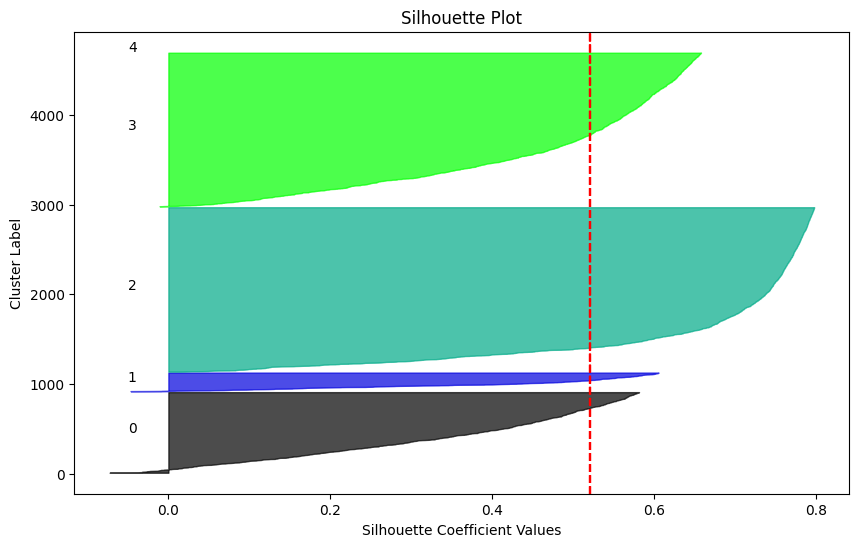

In [93]:
kmeans = KMeans(n_clusters=4, random_state=42)
# Fits the KMeans model on the transformed PCA data, predicts the cluster labels for each data point
kmeans_labels = kmeans.fit_predict(X)

fig, ax = plt.subplots(figsize=(10,6))
silhouette_avg = silhouette_score(X, kmeans_labels)
sample_silhouette_values = silhouette_samples(X, kmeans_labels)
y_lower = 10


for i in range(5):
    cluster_silhouette_values = sample_silhouette_values [kmeans_labels == i]
    cluster_silhouette_values.sort()
    cluster_size = cluster_silhouette_values.shape[0]
    y_upper = y_lower + cluster_size

    color = plt.cm.nipy_spectral(float(i) / 5)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(i))
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    y_lower = y_upper + 10


ax.set_title("Silhouette Plot")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
plt.show ()

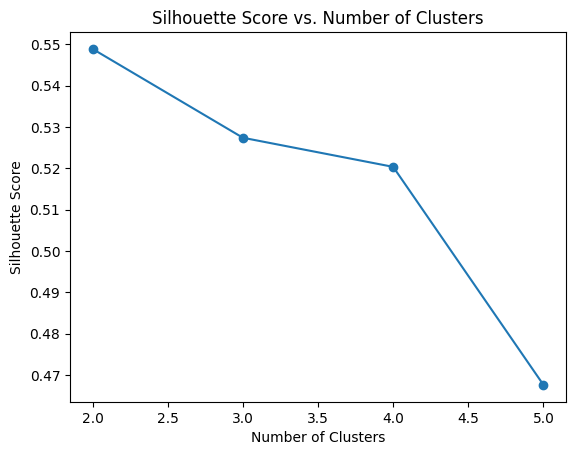

In [94]:
range_n_clusters = list(range (2,6))
silhouette_scores_list = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, kmeans_labels)
    silhouette_scores_list.append(silhouette_avg)

plt.figure()
plt.plot(range_n_clusters, silhouette_scores_list, marker='o')
plt.xlabel('Number of Clusters') 
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

In [95]:
optimal_clusters = range_n_clusters[silhouette_scores_list.index(max(silhouette_scores_list))]
print("Optimal Number of Clusters:", optimal_clusters)

Optimal Number of Clusters: 2


In [96]:
def silhouette_analysis_kmeans(X, range_n_clusters=(2, 3, 4, 5, 6)):
    """
    For each number of clusters in range_n_clusters, this function:
    1. Performs KMeans clustering on X.
    2. Plots the silhouette scores for each cluster (left subplot).
    3. Plots the clustered data in the 2D feature space (right subplot).
    """
    
    for n_clusters in range_n_clusters:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
        
        # Step 1: Run KMeans
        clusterer = KMeans(n_clusters=n_clusters, 
                           n_init="auto", 
                           random_state=42)
        cluster_labels = clusterer.fit_predict(X)
        
        # Step 2: Compute silhouette score
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.3f}")
        
        # Step 3: Compute silhouette scores per sample
        sample_sil_values = silhouette_samples(X, cluster_labels)
        
        # ----- Left plot: silhouette scores -----
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters + 1) * 10 is for space between silhouette plots
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
        
        y_lower = 10
        for i in range(n_clusters):
            # Select and sort silhouette values for cluster i
            ith_cluster_vals = sample_sil_values[cluster_labels == i]
            ith_cluster_vals.sort()
            
            size_cluster_i = ith_cluster_vals.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_vals,
                facecolor=color, 
                edgecolor=color, 
                alpha=0.7
            )
            
            # Label the silhouette plot with cluster numbers
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            
            y_lower = y_upper + 10
        
        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")
        # Average silhouette score vertical line
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])
        ax1.set_xticks(np.linspace(-0.1, 1, 12))
        
        # ----- Right plot: cluster visualization in feature space -----
        # (Here we just use the first 2 columns of X for a 2D scatter plot)
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], 
                    marker='.', s=30, lw=0, 
                    alpha=0.7, c=colors, edgecolor='k')
        
        # Mark the cluster centers
        centers = clusterer.cluster_centers_
        ax2.scatter(centers[:, 0], centers[:, 1], 
                    marker='o', c="white", alpha=1, 
                    s=200, edgecolor='k')
        
        # Label each center with the cluster number
        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], 
                        marker=f'${i}$', alpha=1,
                        s=50, edgecolor='k')
        
        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")
        
        # Main title
        plt.suptitle((f"Silhouette analysis for KMeans clustering on sample data "
                      f"with n_clusters = {n_clusters}"),
                     fontsize=14, fontweight='bold')
        
        plt.show()

In [97]:
# Count data points in each cluster
cluster_sizes = pd.Series(kmeans_labels).value_counts()
cluster_sizes

2    1749
0    1346
3     861
4     557
1     144
Name: count, dtype: int64

For n_clusters = 2, the average silhouette_score is : 0.549


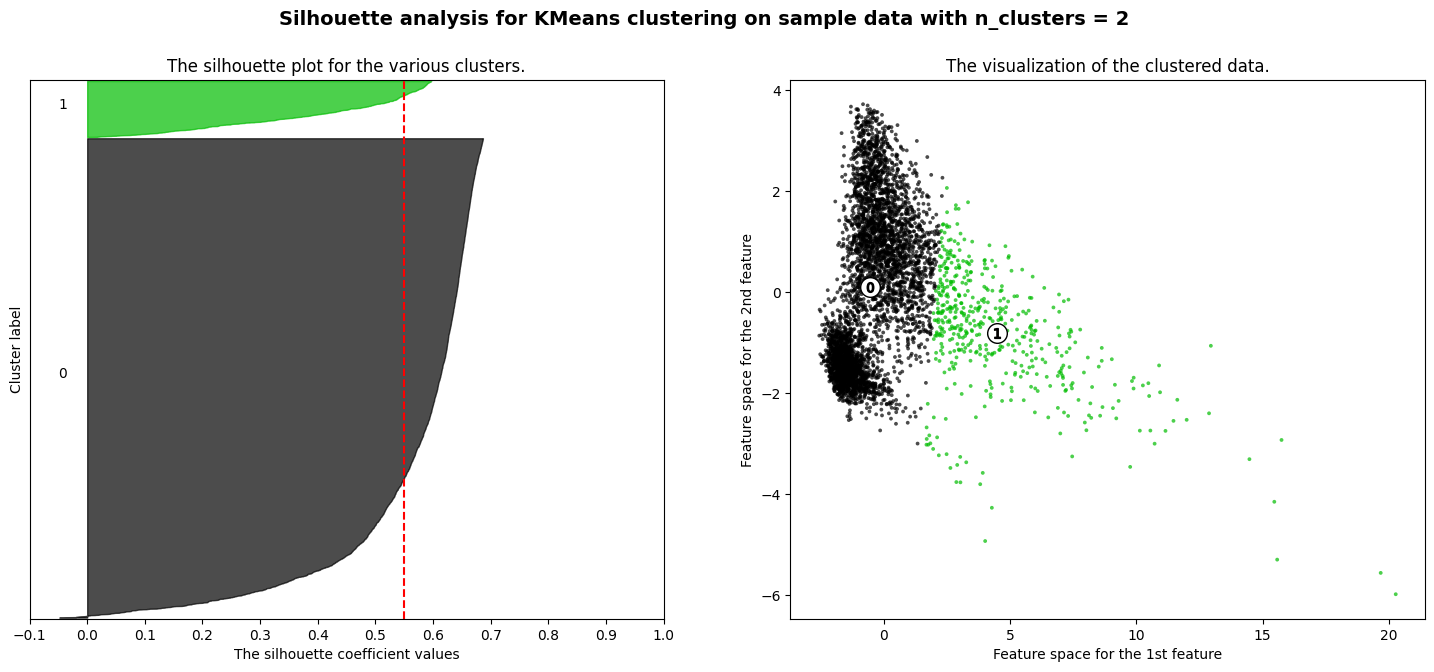

For n_clusters = 3, the average silhouette_score is : 0.527


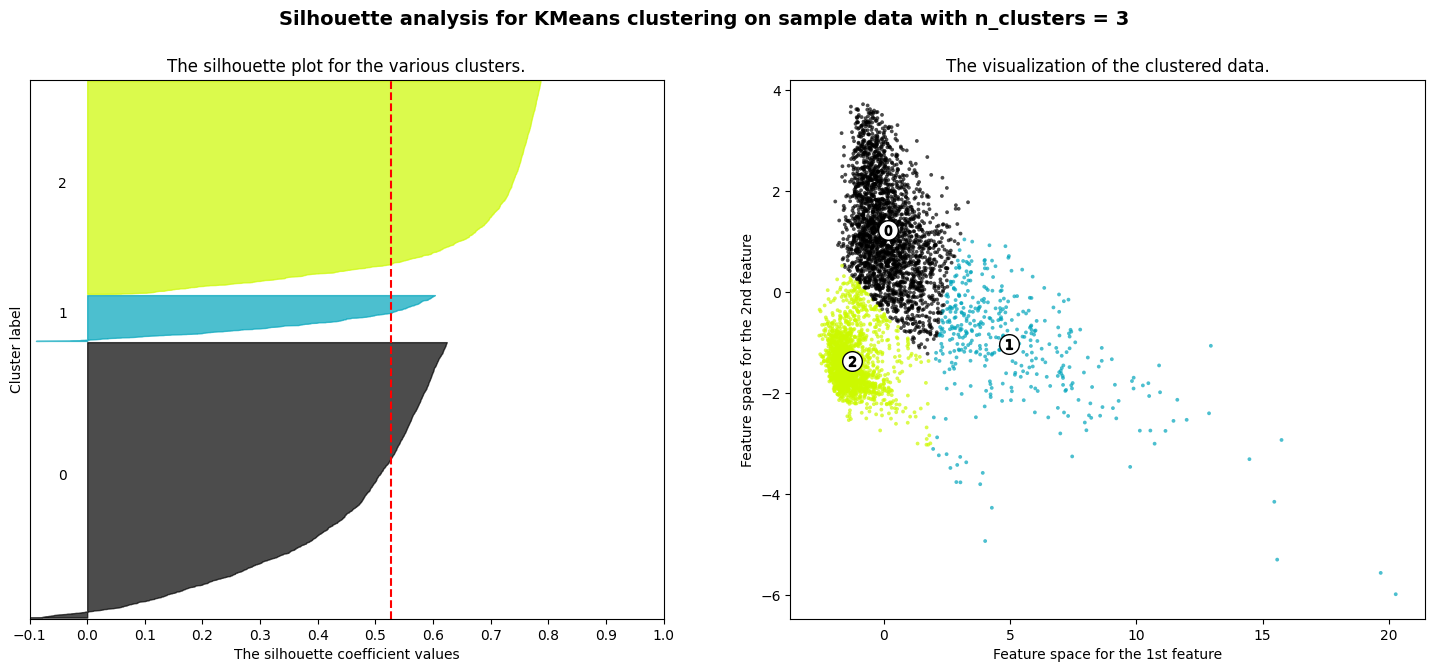

For n_clusters = 4, the average silhouette_score is : 0.520


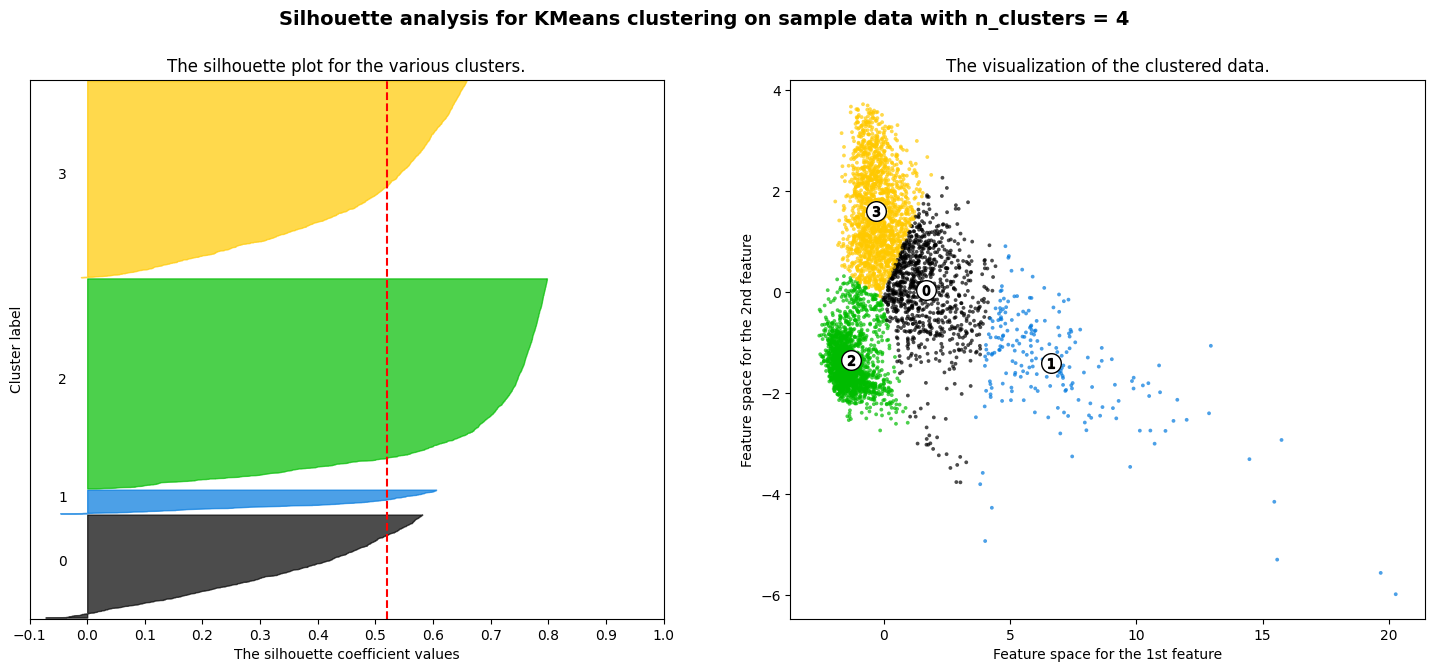

For n_clusters = 5, the average silhouette_score is : 0.468


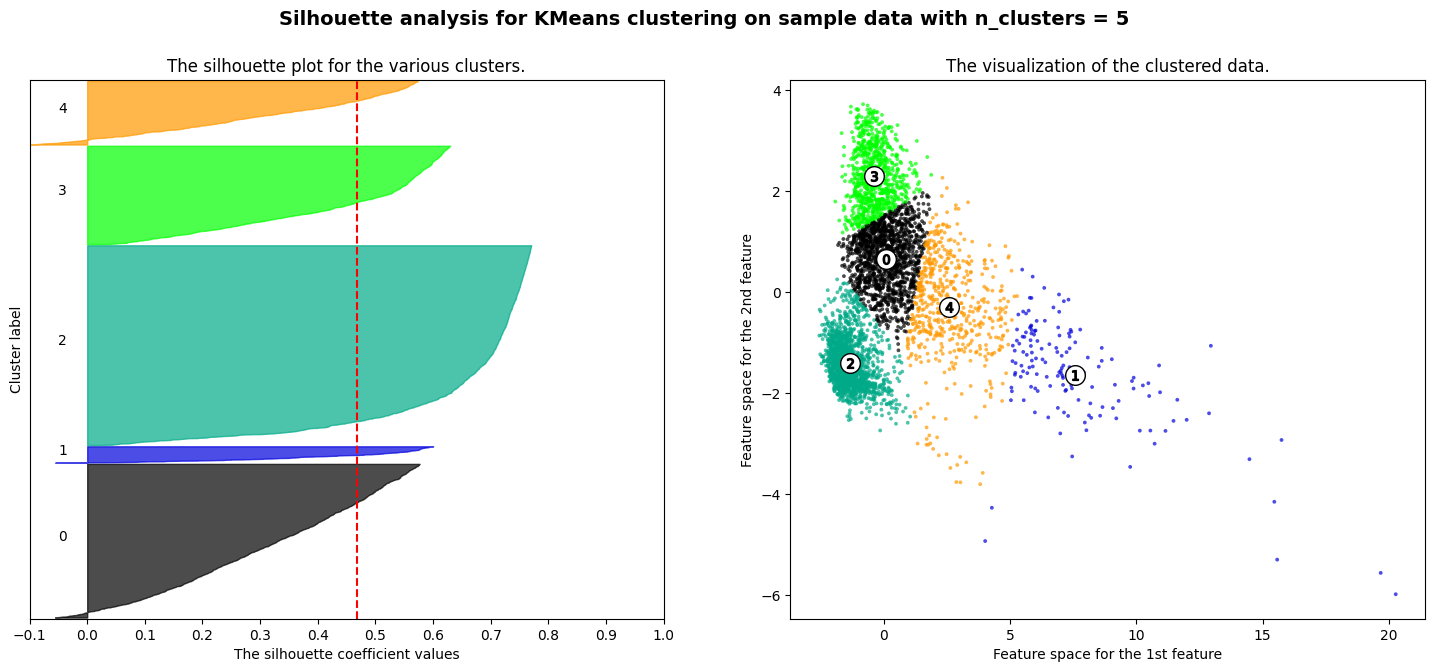

In [98]:
silhouette_analysis_kmeans(X,range_n_clusters=(2, 3, 4, 5))

For n_clusters = 2 The average silhouette_score is : 0.5488928245121244
For n_clusters = 3 The average silhouette_score is : 0.5273995873776598
For n_clusters = 4 The average silhouette_score is : 0.5203543340928567
For n_clusters = 5 The average silhouette_score is : 0.46758887260676874


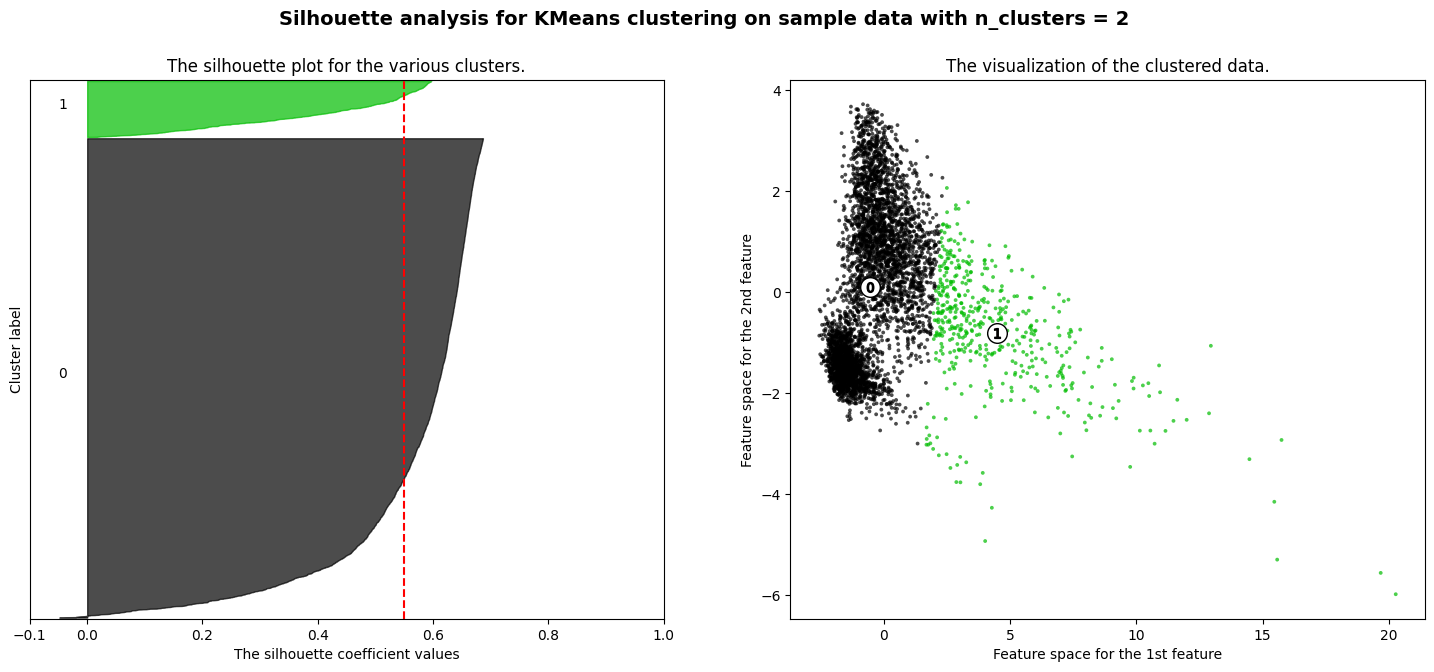

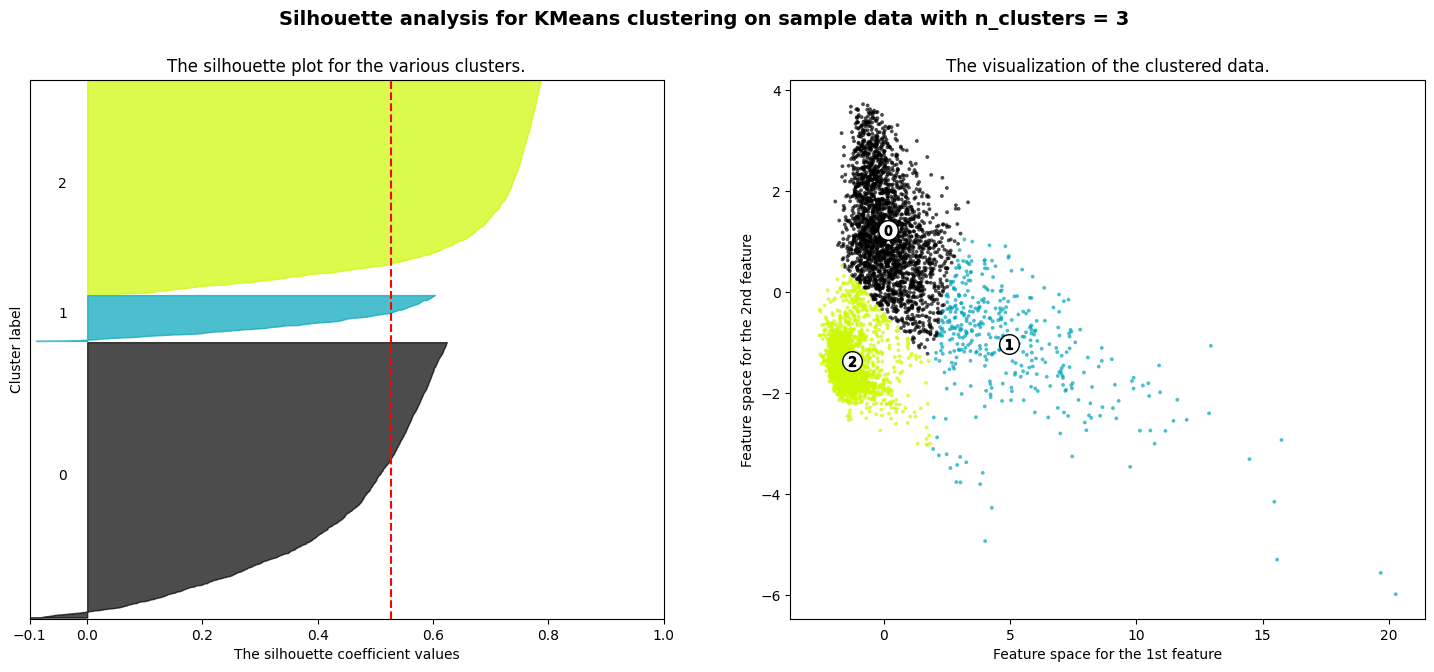

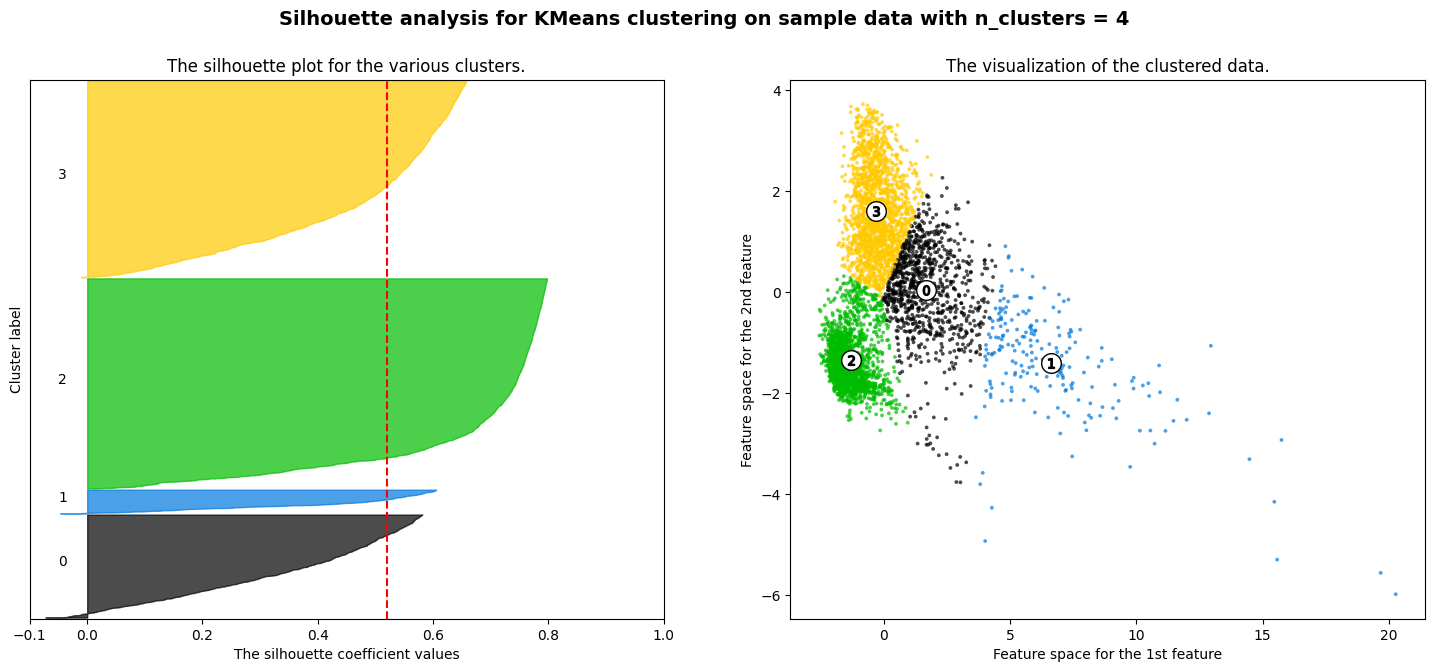

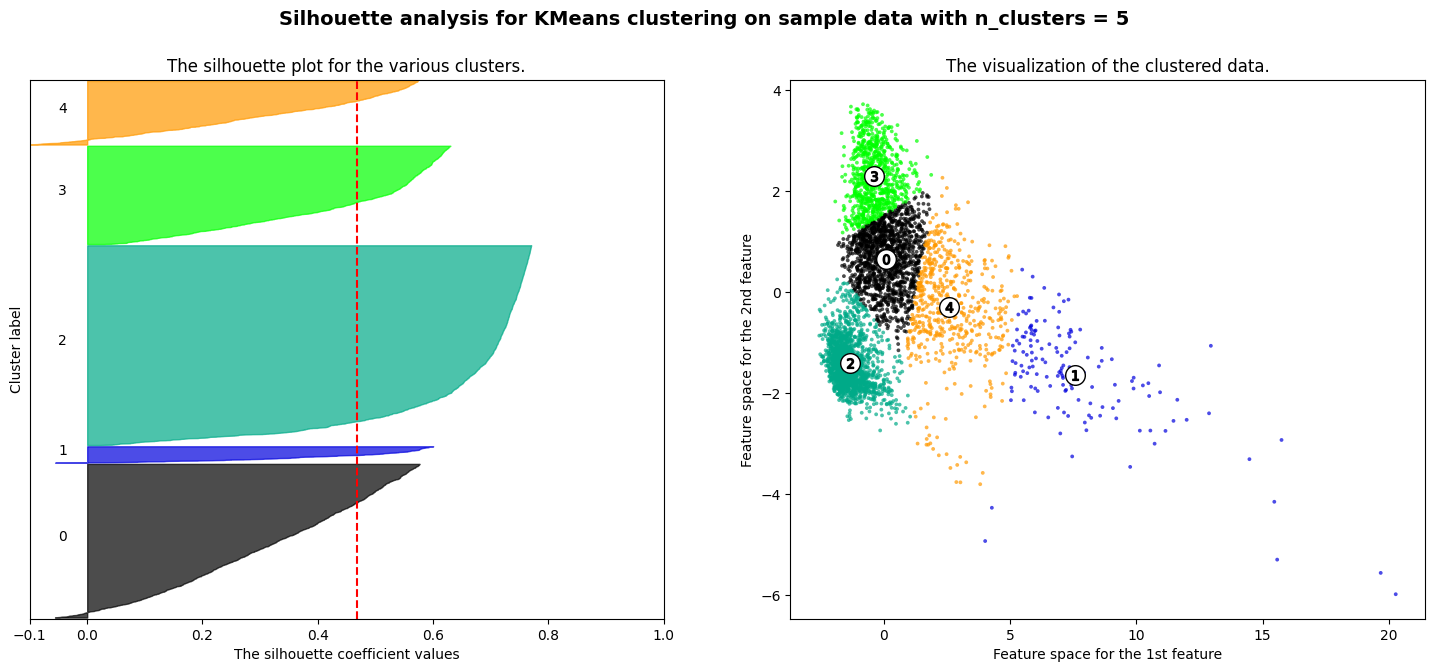

In [99]:
X 
y = kmeans.labels_

range_n_clusters = [2, 3, 4, 5]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 42 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
        "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

In [100]:
# Merged movie dataframe with what cluster they pertain to
clean_movie_df = pd.read_csv('movies_cleaned.csv')
cluster_df = pd.concat([pd.DataFrame(kmeans.labels_).reset_index(),clean_movie_df.reset_index()],axis=1).drop('index',axis=1)

cluster_df

,0,title,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries
0,3,Kate & Leopold (2001),0,118,"['Comedy,Fantasy,Romance']",6.4,91304,56,76019048.0,47121859.0,62.0,28897189.0,38.0,2001,en,['United States of America']
1,0,The Sorcerer's Apprentice (2010),0,86,"['Adventure,Family,Fantasy']",4.2,757,34,215283742.0,63150991.0,29.3,152132751.0,70.7,2010,en,['United States of America']
2,4,Fantastic Four (2005),0,106,"['Action,Adventure,Fantasy']",5.7,353227,11,333535934.0,154696080.0,46.4,178839854.0,53.6,2005,en,"['Germany', 'United States of America']"
3,0,Fantastic Four (2015),0,106,"['Action,Adventure,Fantasy']",5.7,353227,44,167882881.0,56117548.0,33.4,111765333.0,66.6,2015,en,"['United Kingdom', 'Germany', 'United States o..."
4,0,Frida (2002),0,123,"['Biography,Drama,Romance']",7.3,97408,78,56298474.0,25885000.0,46.0,30413474.0,54.0,2002,en,"['Canada', 'Mexico', 'United States of America']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4652,2,The Asadas (2020),0,127,"['Biography,Comedy,Drama']",7.3,1535,97,11888743.0,0.0,0.0,11888743.0,100.0,2020,ja,['Japan']
4653,2,Caught in Time (2020),0,95,"['Action,Crime,Drama']",6.0,1017,20,80543319.0,0.0,0.0,80543319.0,100.0,2020,zh,"['China', 'Hong Kong']"
4654,2,Malang (2020),0,135,"['Action,Crime,Drama']",6.5,12611,127,8399765.0,0.0,0.0,8399765.0,100.0,2020,hi,['India']
4655,2,Moonage Daydream (2022),0,135,"['Biography,Documentary,History']",7.6,15578,145,13095781.0,4218925.0,32.2,8876856.0,67.8,2022,en,"['Germany', 'United States of America']"


In [101]:
cluster_df.groupby(0)['rank'].mean()

0
0     80.778603
1      4.895833
2    135.189251
3    122.121951
4     21.454219
Name: rank, dtype: float64

### Grouping clusters by rank
- cluster 2 (135) and 3 (122) are most similar

In [102]:
cluster_df.groupby(0)['runtimeMinutes'].describe()

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
0,1346.0,106.306092,19.011792,0.0,95.00,105.0,117.0,201.0
1,144.0,135.750000,54.781894,0.0,117.25,136.0,148.0,700.0
2,1749.0,112.818182,23.631203,0.0,99.00,111.0,126.0,213.0
3,861.0,99.209059,19.589460,0.0,90.00,99.0,109.0,219.0
4,557.0,118.028725,22.362672,0.0,104.00,117.0,130.0,206.0


### Grouping by rating
- All clusters are closely related 

In [103]:
cluster_df.groupby(0)['worldwideGross'].describe()

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
0,1346.0,9.506587e+07,5.970881e+07,6274027.0,4.659316e+07,83489884.5,1.310187e+08,3.424631e+08
1,144.0,9.787648e+08,3.891219e+08,278454358.0,7.572872e+08,883680713.0,1.080298e+09,2.799439e+09
2,1749.0,4.077902e+07,4.200528e+07,4693664.0,1.831823e+07,28110245.0,4.649530e+07,3.669619e+08
3,861.0,4.497553e+07,3.169344e+07,4781389.0,2.248337e+07,37270721.0,5.717629e+07,1.914666e+08
4,557.0,3.554534e+08,1.540920e+08,73182700.0,2.363507e+08,332207671.0,4.422993e+08,1.025467e+09


### Groupying by worldwide gross
- culster 0 and 1 closely related

In [104]:
# Grouping by production country
# This produces a MultiIndex Series of counts:
df_cluster_prod = cluster_df.groupby(0)['productionCountries'].value_counts().reset_index(name='count')
print(df_cluster_prod)
df_cluster_prod[df_cluster_prod[0] == 2]

     0                                productionCountries  count
0    0                       ['United States of America']    713
1    0     ['United Kingdom', 'United States of America']     95
2    0             ['Canada', 'United States of America']     45
3    0            ['Germany', 'United States of America']     29
4    0                                 ['United Kingdom']     23
..  ..                                                ...    ...
646  4             ['United States of America', 'France']      1
647  4  ['United States of America', 'Germany', 'Czech...      1
648  4              ['United States of America', 'India']      1
649  4  ['United States of America', 'South Africa', '...      1
650  4              ['United States of America', 'Spain']      1

[651 rows x 3 columns]


,0,productionCountries,count
219,2,['Japan'],335
220,2,['South Korea'],177
221,2,['China'],156
222,2,['France'],114
223,2,['India'],94
...,...,...,...
483,2,"['United Kingdom', 'United States of America',...",1
484,2,"['United States of America', 'China', 'Hong Ko...",1
485,2,"['United States of America', 'France', 'Mexico']",1
486,2,"['United States of America', 'Hong Kong', 'Chi...",1


## Grouping by country
- Cluster 2 is the only one that is not mostly based in United States and it is mostly in asian countries.

In [105]:
df_cluster_prod[df_cluster_prod[0] == 1]


,0,productionCountries,count
209,1,['United States of America'],106
210,1,"['United Kingdom', 'United States of America']",24
211,1,"['New Zealand', 'United States of America']",6
212,1,"['Canada', 'United States of America']",2
213,1,"['China', 'Hong Kong']",1
214,1,"['Germany', 'United States of America']",1
215,1,"['Hungary', 'Norway', 'Sweden']",1
216,1,"['Japan', 'United States of America']",1
217,1,"['United Kingdom', 'United States of America',...",1
218,1,"['United States of America', 'United Kingdom']",1


In [106]:
df_cluster_prod[df_cluster_prod[0] == 0]


,0,productionCountries,count
0,0,['United States of America'],713
1,0,"['United Kingdom', 'United States of America']",95
2,0,"['Canada', 'United States of America']",45
3,0,"['Germany', 'United States of America']",29
4,0,['United Kingdom'],23
...,...,...,...
204,0,"['United States of America', 'New Zealand']",1
205,0,"['United States of America', 'Russia']",1
206,0,"['United States of America', 'United Kingdom',...",1
207,0,"['United States of America', 'United Kingdom',...",1


In [107]:
df_cluster_prod[df_cluster_prod[0] == 3]


,0,productionCountries,count
488,3,['United States of America'],623
489,3,"['Canada', 'United States of America']",32
490,3,"['Germany', 'United States of America']",32
491,3,"['United Kingdom', 'United States of America']",22
492,3,"['Australia', 'United States of America']",13
...,...,...,...
561,3,"['United States of America', 'Australia']",1
562,3,"['United States of America', 'Canada', 'Czech ...",1
563,3,"['United States of America', 'China']",1
564,3,"['United States of America', 'India']",1


In [108]:
df_cluster_prod[df_cluster_prod[0] == 4]


,0,productionCountries,count
566,4,['United States of America'],332
567,4,"['United Kingdom', 'United States of America']",42
568,4,['China'],14
569,4,"['Germany', 'United States of America']",14
570,4,"['Canada', 'United States of America']",9
...,...,...,...
646,4,"['United States of America', 'France']",1
647,4,"['United States of America', 'Germany', 'Czech...",1
648,4,"['United States of America', 'India']",1
649,4,"['United States of America', 'South Africa', '...",1


In [109]:
## Grouping by genre
df_cluster_genre = cluster_df.groupby(0)['genres'].value_counts().reset_index(name='count')
df_cluster_genre[df_cluster_genre[0] == 0]

,0,genres,count
0,0,"['Adventure,Animation,Comedy']",62
1,0,"['Comedy,Drama,Romance']",54
2,0,"['Horror,Mystery,Thriller']",46
3,0,"['Comedy,Romance']",44
4,0,['Drama'],42
...,...,...,...
213,0,['Fantasy'],1
214,0,"['Fantasy,Horror,Thriller']",1
215,0,"['Horror,Sci-Fi']",1
216,0,"['Mystery,Sci-Fi,Thriller']",1


In [110]:
df_cluster_genre[df_cluster_genre[0] == 1]

,0,genres,count
218,1,"['Action,Adventure,Sci-Fi']",30
219,1,"['Adventure,Animation,Comedy']",22
220,1,"['Action,Adventure,Fantasy']",18
221,1,"['Action,Adventure,Comedy']",10
222,1,"['Adventure,Family,Fantasy']",8
223,1,"['Action,Adventure,Thriller']",5
224,1,"['Action,Sci-Fi']",5
225,1,"['Action,Adventure,Animation']",4
226,1,"['Action,Adventure,Drama']",4
227,1,"['Adventure,Drama,Fantasy']",4


In [111]:
df_cluster_genre[df_cluster_genre[0] == 2]

,0,genres,count
255,2,['Comedy'],147
256,2,['Drama'],102
257,2,"['Action,Adventure,Animation']",80
258,2,"['Drama,Romance']",72
259,2,"['Adventure,Animation,Comedy']",61
...,...,...,...
495,2,"['Horror,Sci-Fi']",1
496,2,['Music'],1
497,2,"['Music,Musical']",1
498,2,"['Mystery,Romance,Sci-Fi']",1


In [112]:
df_cluster_genre[df_cluster_genre[0] == 3]

,0,genres,count
500,3,"['Comedy,Romance']",57
501,3,['Comedy'],56
502,3,"['Comedy,Drama,Romance']",51
503,3,['Drama'],45
504,3,"['Comedy,Drama']",37
...,...,...,...
675,3,"['Fantasy,Horror,Thriller']",1
676,3,['Music'],1
677,3,"['Mystery,Thriller']",1
678,3,['Sci-Fi'],1


In [113]:
df_cluster_genre[df_cluster_genre[0] == 4]

,0,genres,count
680,4,"['Adventure,Animation,Comedy']",49
681,4,"['Action,Adventure,Sci-Fi']",43
682,4,"['Action,Adventure,Animation']",25
683,4,"['Action,Adventure,Comedy']",25
684,4,"['Action,Adventure,Fantasy']",24
...,...,...,...
814,4,"['Horror,Mystery,Sci-Fi']",1
815,4,"['Horror,Thriller']",1
816,4,"['Mystery,Romance,Thriller']",1
817,4,"['Mystery,Thriller']",1


In [114]:
cluster_2024_df = cluster_df[cluster_df['year'] == 2024]


In [115]:
cluster_2024_df

,0,title,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries
509,3,Thelma (2024),0,95,['Drama'],6.8,53,139,12419513.0,9002073.0,72.5,3417440.0,27.5,2024,en,"['Switzerland', 'United States of America']"
667,3,Here (2024),0,90,['Drama'],6.9,443,131,14032045.0,12237270.0,87.2,1794775.0,12.8,2024,en,['United States of America']
914,0,Mean Girls (2024),0,97,['Comedy'],7.1,456551,35,104793431.0,72404248.0,69.1,32389183.0,30.9,2024,en,['United States of America']
1261,3,Piece by Piece (2024),0,79,['Documentary'],7.3,146,157,10585957.0,9756635.0,92.2,829322.0,7.8,2024,en,"['Denmark', 'United States of America']"
1443,2,Undercover (2024),0,85,['Comedy'],5.9,90,183,8335766.0,0.0,0.0,8335766.0,100.0,2024,es,['Spain']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4482,2,10 Lives (2024),0,88,"['Animation,Comedy,Family']",5.9,1745,121,16198576.0,0.0,0.0,16198576.0,100.0,2024,en,"['Canada', 'Denmark', 'United Kingdom', 'Unite..."
4541,0,Bob Marley: One Love (2024),0,107,"['Biography,Drama,Music']",6.2,33704,27,180828556.0,96893170.0,53.6,83935386.0,46.4,2024,en,['United States of America']
4565,0,Transformers One (2024),0,104,"['Action,Adventure,Animation']",7.6,45200,31,129364141.0,59054170.0,45.6,70309971.0,54.4,2024,en,['United States of America']
4592,4,Gladiator II (2024),0,148,"['Action,Adventure,Drama']",6.6,200755,11,435153922.0,163053922.0,37.5,272100000.0,62.5,2024,en,['United States of America']


In [116]:
# Doing a groupby with each cluster but 2024 year
df_cluster_2024_prod = cluster_2024_df.groupby(0)['productionCountries'].value_counts().reset_index(name='count')

df_cluster_2024_prod[df_cluster_2024_prod[0] == 0]

,0,productionCountries,count
0,0,['United States of America'],31
1,0,"['United Kingdom', 'United States of America']",5
2,0,['India'],3
3,0,"['Canada', 'United States of America']",2
4,0,"['Australia', 'United Arab Emirates', 'United ...",1
5,0,"['Finland', 'United Kingdom', 'United States o...",1
6,0,"['France', 'Germany', 'United Kingdom', 'Unite...",1
7,0,"['Hong Kong', 'United Kingdom', 'United States...",1
8,0,"['Italy', 'United States of America']",1
9,0,"['Japan', 'New Zealand', 'United States of Ame...",1


In [117]:
df_cluster_2024_prod[df_cluster_2024_prod[0] == 1]


,0,productionCountries,count
14,1,['United States of America'],4
15,1,"['Canada', 'United States of America']",1


In [118]:
df_cluster_2024_prod[df_cluster_2024_prod[0] == 2]


,0,productionCountries,count
16,2,['Japan'],18
17,2,['South Korea'],12
18,2,['France'],9
19,2,['Russia'],5
20,2,['Germany'],4
21,2,['Spain'],4
22,2,[],4
23,2,"['Belgium', 'France']",3
24,2,['Poland'],2
25,2,"['United Kingdom', 'United States of America']",2


In [119]:
df_cluster_2024_prod[df_cluster_2024_prod[0] == 3]


,0,productionCountries,count
46,3,['United States of America'],13
47,3,"['Belgium', 'Ireland']",1
48,3,"['Canada', 'Singapore', 'United States of Amer...",1
49,3,"['Denmark', 'United States of America']",1
50,3,"['Italy', 'United States of America']",1
51,3,"['Netherlands', 'United States of America']",1
52,3,"['Poland', 'United States of America']",1
53,3,"['Slovakia', 'Spain', 'United Kingdom', 'Unite...",1
54,3,"['Switzerland', 'United States of America']",1
55,3,"['United Kingdom', 'United States of America']",1


In [120]:
df_cluster_2024_prod[df_cluster_2024_prod[0] == 4]


,0,productionCountries,count
56,4,['United States of America'],16
57,4,"['Australia', 'United States of America']",1
58,4,"['United States of America', 'Australia']",1


In [121]:
# Now by genre for 2024
df_cluster_2024_genre = cluster_2024_df.groupby(0)['genres'].value_counts().reset_index(name='count')
df_cluster_2024_genre[df_cluster_2024_genre[0] == 0]

,0,genres,count
0,0,['Horror'],5
1,0,['Documentary'],3
2,0,"['Horror,Mystery,Thriller']",3
3,0,"['Action,Adventure,Animation']",2
4,0,"['Adventure,Animation,Comedy']",2
5,0,"['Comedy,Drama,Romance']",2
6,0,"['Horror,Thriller']",2
7,0,"['Action,Adventure,Comedy']",1
8,0,"['Action,Adventure,Crime']",1
9,0,"['Action,Adventure,Drama']",1


In [122]:
df_cluster_2024_genre[df_cluster_2024_genre[0] == 1]

,0,genres,count
39,1,"['Adventure,Animation,Comedy']",3
40,1,"['Action,Adventure,Comedy']",1
41,1,"['Action,Adventure,Drama']",1


In [123]:
df_cluster_2024_genre[df_cluster_2024_genre[0] == 2]

,0,genres,count
42,2,['Comedy'],10
43,2,['Drama'],7
44,2,"['Action,Adventure,Animation']",4
45,2,"['Action,Crime,Thriller']",3
46,2,"['Adventure,Animation,Comedy']",3
47,2,"['Adventure,Comedy,Family']",3
48,2,"['Comedy,Drama']",3
49,2,"['Action,Adventure,Comedy']",2
50,2,"['Biography,Drama,Music']",2
51,2,"['Comedy,Crime,Drama']",2


In [124]:
df_cluster_2024_genre[df_cluster_2024_genre[0] == 3]

,0,genres,count
95,3,"['Biography,Drama,History']",3
96,3,['Drama'],3
97,3,"['Biography,Drama']",2
98,3,['Documentary'],2
99,3,"['Action,Comedy,Thriller']",1
100,3,"['Adventure,Comedy,Drama']",1
101,3,"['Biography,Drama,Music']",1
102,3,['Comedy'],1
103,3,"['Comedy,Documentary']",1
104,3,"['Comedy,Drama']",1


In [125]:
df_cluster_2024_genre[df_cluster_2024_genre[0] == 4]

,0,genres,count
111,4,"['Action,Adventure,Comedy']",2
112,4,"['Action,Adventure,Drama']",2
113,4,"['Action,Adventure,Sci-Fi']",2
114,4,"['Action,Adventure,Animation']",1
115,4,"['Action,Adventure,Fantasy']",1
116,4,"['Action,Adventure,Thriller']",1
117,4,"['Action,Comedy,Drama']",1
118,4,"['Adventure,Animation,Drama']",1
119,4,"['Animation,Sci-Fi']",1
120,4,"['Comedy,Fantasy,Horror']",1


In [126]:
cluster_2024_df.groupby(0)['rank'].describe()


,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
0,51.0,71.627451,41.514798,21.0,38.50,64.0,90.00,196.0
1,5.0,3.000000,1.581139,1.0,2.00,3.0,4.00,5.0
2,86.0,126.279070,46.313167,34.0,94.50,127.5,168.75,199.0
3,22.0,127.681818,42.648493,58.0,94.75,136.0,160.75,200.0
4,18.0,15.111111,6.388306,6.0,10.25,14.5,18.75,28.0


In [127]:
cluster_df.groupby(0)['rank'].describe()

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
0,1346.0,80.778603,41.795164,10.0,49.0,71.0,106.00,200.0
1,144.0,4.895833,4.214060,1.0,2.0,4.0,6.25,34.0
2,1749.0,135.189251,46.077640,8.0,103.0,144.0,174.00,200.0
3,861.0,122.121951,42.560821,21.0,91.0,120.0,156.00,200.0
4,557.0,21.454219,12.510433,1.0,12.0,19.0,28.00,73.0


# Agglomerative Clustering

In [128]:
ppd = pd.read_csv('preprocessed_movie_data.csv')
ppd2 = pd.read_csv('preprocessed_movie_data2.csv')

In [129]:
# Create a pipeline for preprocessing
pipeline = Pipeline(
    [
    ('impute',SimpleImputer(strategy='constant',fill_value=1)),
    ('scale',StandardScaler()),
    ('pca', PCA(n_components=3,random_state=42)),
    ]
)

In [130]:
# Fit the pipeline to the ppd data
# Drop unnecessary columns if they exist
columns_to_drop = ['movieId', 'title', 'Unnamed: 0']
X = ppd.drop(columns=[col for col in columns_to_drop if col in ppd.columns])
X_transformed = pipeline.fit_transform(X)
# Perform clustering
clustering = AgglomerativeClustering(n_clusters=5)
clusters = clustering.fit_predict(X_transformed)

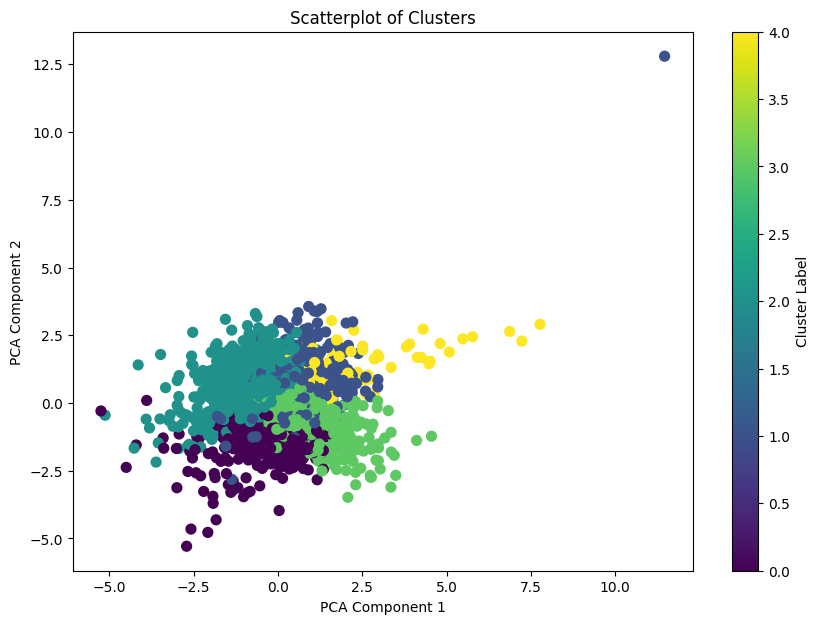

In [131]:
# Create Scatterplot for ppd data

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Scatterplot of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')  # Optional: if you want a color bar for reference
plt.show()

In [132]:
# Fit the pipeline to the ppd2 data
# Drop unnecessary columns if they exist
columns_to_drop2 = ['movieId', 'title', 'Unnamed: 0']
X2 = ppd2.drop(columns=[col for col in columns_to_drop2 if col in ppd2.columns])
# Adjust PCA to match the number of features in ppd2
pipeline.steps[-1] = ('pca', PCA(n_components=2, random_state=42))
X_transformed2 = pipeline.fit_transform(X2)
# Perform clustering
clustering2 = AgglomerativeClustering(n_clusters=5)
clusters2 = clustering.fit_predict(X_transformed2)

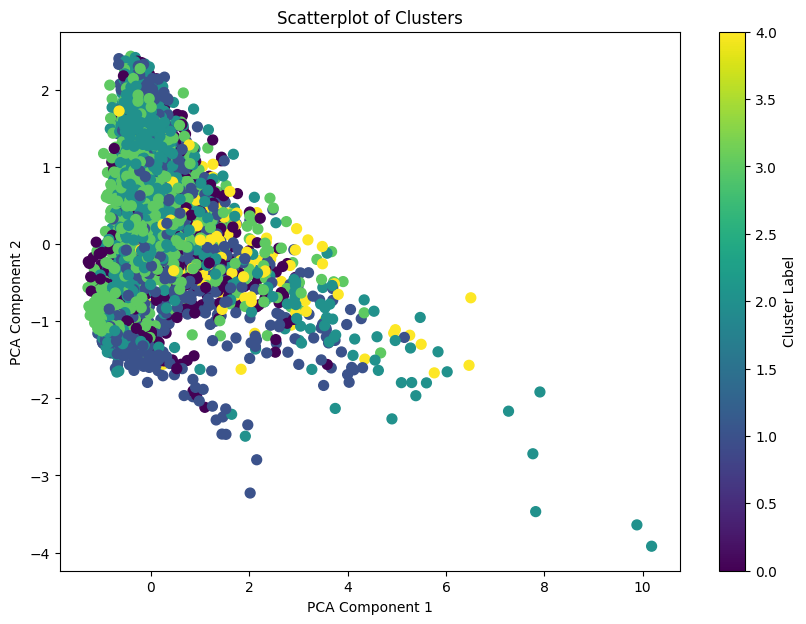

In [133]:
# Create Scatterplot for ppd2

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed2[:, 0], X_transformed2[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Scatterplot of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')  # Optional: if you want a color bar for reference
plt.show()

In [134]:
# Create labels for the clusters
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']
# Create a DataFrame to hold the cluster labels
cluster_labels = pd.DataFrame({'title': ppd['title'], 'Cluster': clusters})
# Merge the cluster labels with the original DataFrame
merged_df = pd.merge(ppd, cluster_labels, on='title')

In [135]:
merged_df

,title,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Cluster
0,Kate & Leopold (2001),0.365811,1.674679,0.697536,-0.867474,0.614986,-0.760826,-0.510062,0
1,The Sorcerer's Apprentice (2010),0.334949,0.253406,-2.369158,-0.666094,0.655086,-0.872105,0.037816,0
2,Fantastic Four (2005),2.526709,0.662646,-0.605463,-1.021418,0.427681,-0.646847,0.422886,0
3,Fantastic Four (2015),0.987338,-0.072774,-0.460300,0.127163,-0.002844,-0.730169,1.113554,3
4,Frida (2002),0.075308,0.845189,1.396535,-0.896946,0.162305,-0.574121,-0.671469,1
...,...,...,...,...,...,...,...,...,...
4652,The Asadas (2020),-1.136747,-1.976078,0.795535,0.776484,-0.375664,-0.515400,-0.369464,2
4653,Caught in Time (2020),-0.588399,-1.671850,-1.142717,0.411517,-0.554540,-1.582273,-0.081351,0
4654,Malang (2020),-1.393844,-1.922148,0.551073,0.809941,0.373365,-0.083533,0.048234,1
4655,Moonage Daydream (2022),-0.910854,-0.613656,1.329126,1.638163,-0.272824,0.394038,-0.359412,2


In [138]:
# Merged movie dataframe with what cluster they pertain to
clean_movie_df = pd.read_csv('movies_cleaned.csv')
agg_cluster_df = pd.concat([pd.DataFrame(clusters2).reset_index(),clean_movie_df.reset_index()],axis=1).drop('index',axis=1)

agg_cluster_df

,0,title,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries
0,4,Kate & Leopold (2001),0,118,"['Comedy,Fantasy,Romance']",6.4,91304,56,76019048.0,47121859.0,62.0,28897189.0,38.0,2001,en,['United States of America']
1,2,The Sorcerer's Apprentice (2010),0,86,"['Adventure,Family,Fantasy']",4.2,757,34,215283742.0,63150991.0,29.3,152132751.0,70.7,2010,en,['United States of America']
2,1,Fantastic Four (2005),0,106,"['Action,Adventure,Fantasy']",5.7,353227,11,333535934.0,154696080.0,46.4,178839854.0,53.6,2005,en,"['Germany', 'United States of America']"
3,1,Fantastic Four (2015),0,106,"['Action,Adventure,Fantasy']",5.7,353227,44,167882881.0,56117548.0,33.4,111765333.0,66.6,2015,en,"['United Kingdom', 'Germany', 'United States o..."
4,2,Frida (2002),0,123,"['Biography,Drama,Romance']",7.3,97408,78,56298474.0,25885000.0,46.0,30413474.0,54.0,2002,en,"['Canada', 'Mexico', 'United States of America']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4652,3,The Asadas (2020),0,127,"['Biography,Comedy,Drama']",7.3,1535,97,11888743.0,0.0,0.0,11888743.0,100.0,2020,ja,['Japan']
4653,3,Caught in Time (2020),0,95,"['Action,Crime,Drama']",6.0,1017,20,80543319.0,0.0,0.0,80543319.0,100.0,2020,zh,"['China', 'Hong Kong']"
4654,3,Malang (2020),0,135,"['Action,Crime,Drama']",6.5,12611,127,8399765.0,0.0,0.0,8399765.0,100.0,2020,hi,['India']
4655,3,Moonage Daydream (2022),0,135,"['Biography,Documentary,History']",7.6,15578,145,13095781.0,4218925.0,32.2,8876856.0,67.8,2022,en,"['Germany', 'United States of America']"
